<a href="https://colab.research.google.com/github/Mario-Cattaneo/SemesterProject/blob/main/Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Imports and Device Setup
import copy
import math
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cuda


In [2]:
# Cell 2: Hierarchical Configuration with Unified Time Units (ms & bits)
from dataclasses import dataclass, field
import math
from typing import Dict, List, Tuple
import numpy as np
import torch
import torch.nn as nn


@dataclass
class ChannelConfig:
    capacity_bits_per_ms: (
        float  # Capacity in bits/ms (e.g., 30 Mbps = 30,000 bits/ms)
    )
    prop_delay_ms: float  # Propagation delay in ms
    bit_width: int = 8  # b bits per scalar component

    @classmethod
    def from_mbps(cls, capacity_mbps: float, prop_delay_ms: float, bit_width=8):
        """Helper: converts Mbps to bits/ms (1 Mbps = 1,000 bits/ms)."""
        return cls(
            capacity_bits_per_ms=capacity_mbps * 1000.0,
            prop_delay_ms=prop_delay_ms,
            bit_width=bit_width,
        )


@dataclass
class NodeConfig:
    device_name: str
    exec_time_ms: float  # Device execution delay t_i^exec in ms


@dataclass
class ToleranceConfig:
    epsilon_ms: float = 0.8  # Global tolerance band [t_target - eps, t_target]
    epsilon_margin_ms: float = (
        0.3  # Max allowed SLA ceiling margin (t_target + margin)
    )


@dataclass
class ALMConfig:
    t_max: float  # Target SLA in ms
    lambda1_init: float = 0.0
    lambda2_init: float = 0.005
    rho: float = 1.5
    tau_viol: float = 0.25
    e_step: int = 2


@dataclass
class GateConfig:
    alpha: float = 10.0  # Smooth-max sharpness (constant)
    beta_init: float = 1.5
    beta_min: float = 0.05
    decay_rate: float = 0.90
    gamma: float = -0.1
    zeta: float = 1.1
    s_init: float = 1.0


@dataclass
class ExperimentConfig:
    experiment_name: str = "TBN_Component_Level"
    batch_size: int = 128
    epochs: int = 8
    lr_s: float = 0.05  # Learning rate for component gates
    lr_c: float = 0.01  # Learning rate for continuous imputations
    nodes: Dict[int, NodeConfig] = field(default_factory=dict)
    edges: Dict[Tuple[int, int], ChannelConfig] = field(default_factory=dict)
    alm: ALMConfig = field(default_factory=lambda: ALMConfig(t_max=25.0))
    gate: GateConfig = field(default_factory=GateConfig)
    tolerance: ToleranceConfig = field(default_factory=ToleranceConfig)


print("Cell 2: Unified configuration layer ready.")

Cell 2: Unified configuration layer ready.


In [3]:
# Cell 3: True Component-Level (Element-Wise) Gating and Imputation


class EdgeBottleneck(nn.Module):
    """Component-level gating: learns one gate s and one imputation c for every

    individual scalar feature k in D_{i,j}.
    """

    def __init__(
        self,
        feature_shape: Tuple[int, ...],
        channel_cfg: ChannelConfig,
        gate_cfg: GateConfig,
    ):
        super().__init__()
        self.feature_shape = feature_shape  # e.g., (32, 32, 32)
        self.channel_cfg = channel_cfg
        self.gate_cfg = gate_cfg

        self.total_components = int(np.prod(feature_shape))

        # s and c match the EXACT tensor dimensions (C, H, W)
        self.s = nn.Parameter(torch.full(feature_shape, gate_cfg.s_init))
        self.c = nn.Parameter(torch.zeros(feature_shape))

    def get_transmission_prob(self, beta: float) -> torch.Tensor:
        """p(m_i,j^(k) > 0) evaluated component-wise."""
        offset = beta * math.log(-self.gate_cfg.gamma / self.gate_cfg.zeta)
        return torch.sigmoid(self.s - offset)

    def expected_transmission_time_ms(self, beta: float) -> torch.Tensor:
        """t_trans = (b * E[|Omega|]) / C [bits / (bits/ms) = ms]."""
        probs = self.get_transmission_prob(beta)
        expected_active_components = torch.sum(probs)
        total_bits = expected_active_components * self.channel_cfg.bit_width
        # Direct unified division: bits / (bits/ms) = ms
        trans_time_ms = total_bits / self.channel_cfg.capacity_bits_per_ms
        return trans_time_ms

    def forward(
        self, z: torch.Tensor, beta: float, deterministic: bool = False
    ) -> Tuple[torch.Tensor, float]:
        s_broad = self.s.unsqueeze(0)
        c_broad = self.c.unsqueeze(0)

        if not deterministic:
            eps = torch.rand_like(s_broad).clamp(1e-6, 1.0 - 1e-6)
            logits_eps = torch.log(eps) - torch.log(1.0 - eps)
            m_tilde = torch.sigmoid((logits_eps + s_broad) / beta)
            m_bar = (
                m_tilde * (self.gate_cfg.zeta - self.gate_cfg.gamma)
                + self.gate_cfg.gamma
            )
            m = torch.clamp(m_bar, 0.0, 1.0)

            # u^(k) = z^(k) * m^(k) + (1 - m^(k)) * c^(k)
            u = z * m + (1.0 - m) * c_broad
            active_fraction = float(m.mean().item())
            return u, active_fraction
        else:
            threshold = beta * math.log(
                -self.gate_cfg.gamma / self.gate_cfg.zeta
            )
            hard_mask = (s_broad >= threshold).float()

            u = z * hard_mask + (1.0 - hard_mask) * c_broad
            active_fraction = float(hard_mask.mean().item())
            return u, active_fraction


print("Cell 3: Component-level EdgeBottleneck compiled.")

Cell 3: Component-level EdgeBottleneck compiled.


In [4]:
# Cell 4: DAGTimingEngine with Direct Millisecond Summation


class DAGTimingEngine:

    def __init__(
        self,
        nodes: Dict[int, NodeConfig],
        edges: Dict[Tuple[int, int], ChannelConfig],
    ):
        self.nodes = nodes
        self.edges = edges

        self.parents: Dict[int, List[int]] = {i: [] for i in nodes}
        self.children: Dict[int, List[int]] = {i: [] for i in nodes}
        for u, v in edges.keys():
            self.parents[v].append(u)
            self.children[u].append(v)

        self.topo_order = self._get_topological_sort()
        self.terminal_node = self.topo_order[-1]

    def _get_topological_sort(self) -> List[int]:
        in_deg = {i: len(self.parents[i]) for i in self.nodes}
        queue = [i for i in self.nodes if in_deg[i] == 0]
        order = []
        while queue:
            curr = queue.pop(0)
            order.append(curr)
            for nxt in self.children[curr]:
                in_deg[nxt] -= 1
                if in_deg[nxt] == 0:
                    queue.append(nxt)
        return order

    def compute_relaxed_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        alpha: float,
    ) -> torch.Tensor:
        t_tilde: Dict[int, torch.Tensor] = {}

        for j in self.topo_order:
            t_exec = torch.tensor(
                self.nodes[j].exec_time_ms, device=bottlenecks[(0, 1)].s.device
            )

            if len(self.parents[j]) == 0:
                t_tilde[j] = t_exec
            else:
                branch_arrivals = []
                for i in self.parents[j]:
                    t_trans = bottlenecks[(i, j)].expected_transmission_time_ms(
                        beta
                    )
                    t_prop = torch.tensor(
                        self.edges[(i, j)].prop_delay_ms, device=t_trans.device
                    )
                    z_ij = (
                        t_tilde[i] + t_prop + t_trans
                    )  # All terms strictly in ms
                    branch_arrivals.append(z_ij)

                stacked = torch.stack(branch_arrivals)
                z_max = torch.max(stacked).detach()
                lse = z_max + (1.0 / alpha) * torch.log(
                    torch.sum(torch.exp(alpha * (stacked - z_max)))
                )
                t_tilde[j] = t_exec + lse

        return t_tilde[self.terminal_node]

    def compute_physical_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        deterministic: bool = True,
    ) -> float:
        t_physical: Dict[int, float] = {}

        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms

            if len(self.parents[j]) == 0:
                t_physical[j] = t_exec
            else:
                branch_delays = []
                for i in self.parents[j]:
                    bneck = bottlenecks[(i, j)]
                    if deterministic:
                        thresh = beta * math.log(
                            -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
                        )
                        active_components = (bneck.s >= thresh).sum().item()
                    else:
                        active_components = (
                            bneck.get_transmission_prob(beta).sum().item()
                        )

                    total_bits = (
                        active_components * bneck.channel_cfg.bit_width
                    )
                    # bits / (bits/ms) = ms
                    t_trans = (
                        total_bits / self.edges[(i, j)].capacity_bits_per_ms
                    )
                    t_prop = self.edges[(i, j)].prop_delay_ms
                    branch_delays.append(t_physical[i] + t_prop + t_trans)

                t_physical[j] = t_exec + max(branch_delays)

        return t_physical[self.terminal_node]

    def compute_irreducible_latency(self) -> float:
        """Physical floor when t_trans -> 0 (ms)."""
        t_floor: Dict[int, float] = {}
        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms
            if len(self.parents[j]) == 0:
                t_floor[j] = t_exec
            else:
                branch_delays = [
                    t_floor[i] + self.edges[(i, j)].prop_delay_ms
                    for i in self.parents[j]
                ]
                t_floor[j] = t_exec + max(branch_delays)
        return t_floor[self.terminal_node]


print("Cell 4: DAGTimingEngine ready.")

Cell 4: DAGTimingEngine ready.


In [5]:
# Cell 5: Collaborative ResNet DAG with Residual Micro-Splits


class ResBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return F.relu(x + self.conv(x))


class CollaborativeResNetDAG(nn.Module):

    def __init__(self, cfg: ExperimentConfig):
        super().__init__()
        self.cfg = cfg

        # Device 0: Input Stem + ResBlock (Outputs 64 channels)
        self.node0_split = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 1: Parallel Worker A (Processes 32 channels -> outputs 64)
        self.node1_split = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 2: Parallel Worker B (Processes 32 channels -> outputs 64)
        self.node2_split = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 3: Concatenation (64+64 = 128 channels) + ResBlock + Classifier
        self.node3_split = nn.Sequential(
            ResBlock(128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 10),
        )

        # EdgeBottlenecks for directed channels
        self.bottlenecks = nn.ModuleDict()
        self.bottlenecks["0->1"] = EdgeBottleneck(
            (32, 32, 32), cfg.edges[(0, 1)], cfg.gate
        )
        self.bottlenecks["0->2"] = EdgeBottleneck(
            (32, 32, 32), cfg.edges[(0, 2)], cfg.gate
        )
        self.bottlenecks["1->3"] = EdgeBottleneck(
            (64, 16, 16), cfg.edges[(1, 3)], cfg.gate
        )
        self.bottlenecks["2->3"] = EdgeBottleneck(
            (64, 16, 16), cfg.edges[(2, 3)], cfg.gate
        )

    def get_bottleneck_map(self) -> Dict[Tuple[int, int], EdgeBottleneck]:
        return {
            (0, 1): self.bottlenecks["0->1"],
            (0, 2): self.bottlenecks["0->2"],
            (1, 3): self.bottlenecks["1->3"],
            (2, 3): self.bottlenecks["2->3"],
        }

    def forward(
        self, x: torch.Tensor, beta: float, deterministic: bool = False
    ) -> torch.Tensor:
        z0 = self.node0_split(x)
        z0_A, z0_B = torch.split(z0, 32, dim=1)

        u01, _ = self.bottlenecks["0->1"](
            z0_A, beta, deterministic=deterministic
        )
        u02, _ = self.bottlenecks["0->2"](
            z0_B, beta, deterministic=deterministic
        )

        z1 = self.node1_split(u01)
        z2 = self.node2_split(u02)

        u13, _ = self.bottlenecks["1->3"](
            z1, beta, deterministic=deterministic
        )
        u23, _ = self.bottlenecks["2->3"](
            z2, beta, deterministic=deterministic
        )

        z_concat = torch.cat([u13, u23], dim=1)
        return self.node3_split(z_concat)


print("Cell 5: Upgraded residual architecture ready.")

Cell 5: Upgraded residual architecture ready.


In [6]:
# ==============================================================================
# Cell 6: Symmetrical UnifiedTradeoffTrainer with Warm-Start & Temperature Control
# ==============================================================================
import copy
import torch.optim as optim


class UnifiedTradeoffTrainer:
    """Symmetrical trainer for all 3 unconstrained approaches:

    - 'uniform_bits': L_task + beta * Sum(Raw Bits)
    - 'capacity_delay': L_task + mu * Sum(Raw Transmission Delays in ms)
    - 'critical_path': L_task + gamma * Critical-Path Latency (tilde{t} in ms)
    """

    def __init__(
        self,
        model: CollaborativeResNetDAG,
        timing_engine: DAGTimingEngine,
        cfg: ExperimentConfig,
        weight: float,
        mode: str,
        lr_s: float = None,
        lr_c: float = None,
    ):
        self.model = model.to(device)
        self.timing_engine = timing_engine
        self.cfg = cfg
        self.weight = weight
        self.mode = mode

        s_params = [
            bneck.s for bneck in self.model.get_bottleneck_map().values()
        ]
        c_params = [
            bneck.c for bneck in self.model.get_bottleneck_map().values()
        ]
        self.optimizer = optim.Adam(
            [
                {"params": s_params, "lr": lr_s if lr_s is not None else cfg.lr_s},
                {"params": c_params, "lr": lr_c if lr_c is not None else cfg.lr_c},
            ]
        )
        self.criterion = nn.CrossEntropyLoss()

    def train_epoch(
        self,
        dataloader,
        epoch: int = 0,
        max_batches: int = None,
        beta: float = None,
    ) -> float:
        self.model.train()
        # If beta is explicitly passed, use it directly (prevents temperature shock during fine-tuning)
        if beta is None:
            beta = max(
                self.cfg.gate.beta_min,
                self.cfg.gate.beta_init * (self.cfg.gate.decay_rate**epoch),
            )

        bneck_map = self.model.get_bottleneck_map()
        running_loss = 0.0

        for b_idx, (x, y) in enumerate(dataloader):
            if max_batches and b_idx >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            self.optimizer.zero_grad()

            y_hat = self.model(x, beta=beta, deterministic=False)
            task_loss = self.criterion(y_hat, y)

            if self.mode == "uniform_bits":
                total_bits = sum(
                    torch.sum(bneck.get_transmission_prob(beta))
                    * bneck.channel_cfg.bit_width
                    for bneck in bneck_map.values()
                )
                penalty = self.weight * total_bits

            elif self.mode == "capacity_delay":
                total_delay_ms = sum(
                    bneck.expected_transmission_time_ms(beta)
                    for bneck in bneck_map.values()
                )
                penalty = self.weight * total_delay_ms

            elif self.mode == "critical_path":
                tilde_t = self.timing_engine.compute_relaxed_latency(
                    bneck_map, beta=beta, alpha=self.cfg.gate.alpha
                )
                penalty = self.weight * tilde_t

            loss = task_loss + penalty
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()

        return running_loss / (max_batches if max_batches else len(dataloader))

    @torch.no_grad()
    def evaluate(self, dataloader) -> Tuple[float, float, Dict[str, float]]:
        self.model.eval()
        correct, total = 0, 0
        beta_eval = self.cfg.gate.beta_min
        bneck_map = self.model.get_bottleneck_map()

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            y_hat = self.model(x, beta=beta_eval, deterministic=True)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)

        acc = 100.0 * correct / total
        lat = self.timing_engine.compute_physical_latency(
            bneck_map, beta=beta_eval, deterministic=True
        )

        retained = {}
        for edge_key, bneck in bneck_map.items():
            thresh = beta_eval * math.log(
                -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
            )
            retained[f"{edge_key[0]}->{edge_key[1]}"] = (
                (bneck.s >= thresh).float().mean().item() * 100.0
            )

        return acc, lat, retained


print("Cell 6: UnifiedTradeoffTrainer upgraded with warm-start & beta support.")

Cell 6: UnifiedTradeoffTrainer upgraded with warm-start & beta support.


In [7]:
# ==============================================================================
# Cell 6B: High-Speed CDN Dataset + Self-Healing Checkpoint Loader
# ==============================================================================
import copy
import os
import shutil
import tarfile
import urllib.request
from google.colab import drive
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# ------------------------------------------------------------------------------
# 1. Download CIFAR-10 from High-Speed CDN Mirror (~2-3 seconds at 80 MB/s)
# ------------------------------------------------------------------------------
local_cifar_dir = "/content/cifar10_local"
target_batch_dir = os.path.join(local_cifar_dir, "cifar-10-batches-py")

if not os.path.exists(target_batch_dir):
    os.makedirs(local_cifar_dir, exist_ok=True)
    tar_archive_path = "/content/cifar-10-python.tar.gz"

    # Fast Cloudflare/HuggingFace CDN mirror (Bypasses slow Toronto server)
    cdn_url = "https://huggingface.co/datasets/Shiym/ViT-FineTune/resolve/main/cifar-10-python.tar.gz"

    if not os.path.exists(tar_archive_path):
        print(
            "Downloading CIFAR-10 from high-speed Cloudflare CDN (~2-3s at 80 MB/s)..."
        )
        urllib.request.urlretrieve(cdn_url, tar_archive_path)

    print("Extracting dataset...")
    with tarfile.open(tar_archive_path, "r:gz") as tar:
        tar.extractall(path=local_cifar_dir)
    print(">>> CIFAR-10 ready on fast local disk!")
else:
    print("CIFAR-10 already cached locally.")

# ------------------------------------------------------------------------------
# 2. Setup DataLoaders (Local, num_workers=0)
# ------------------------------------------------------------------------------
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ]
)
transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=local_cifar_dir, train=True, download=False, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root=local_cifar_dir, train=False, download=False, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(
    f"DataLoaders ready: {len(trainset)} train, {len(testset)} test samples."
)

# ------------------------------------------------------------------------------
# 3. Checkpoint Resolution: Load Existing OR Pretrain Once Automatically
# ------------------------------------------------------------------------------
checkpoint_path = "/content/universal_resnet_split.pt"
drive_path = "/content/drive/MyDrive/Colab_Datasets/universal_resnet_split.pt"

# Check if Drive is mounted and contains the file
if not os.path.exists(checkpoint_path) and os.path.exists(drive_path):
    print(f"Copying checkpoint from Drive: {drive_path}...")
    shutil.copy(drive_path, checkpoint_path)


def is_valid_model_file(filepath):
    if not os.path.exists(filepath):
        return False
    try:
        with open(filepath, "rb") as f:
            header = f.read(16)
            if header.startswith(b"<"):  # HTML check
                return False
        return os.path.getsize(filepath) > 1e6
    except Exception:
        return False


if is_valid_model_file(checkpoint_path):
    print(f"\nLoading universal checkpoint from: {checkpoint_path}")
    pretrained_weights = torch.load(
        checkpoint_path, map_location=device, weights_only=False
    )
    print(
        ">>> Checkpoint loaded in 0.1s! Ready to run Cell 7 without training."
    )
else:
    print("\nCheckpoint not found on disk. Pretraining universal backbone ONCE")
    print("on your T4 GPU (20 epochs, ~2.5 mins)...")

    dummy_cfg = ExperimentConfig(
        nodes={
            0: NodeConfig("N0", 1.0),
            1: NodeConfig("N1", 1.0),
            2: NodeConfig("N2", 1.0),
            3: NodeConfig("N3", 1.0),
        },
        edges={
            (0, 1): ChannelConfig.from_mbps(10.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(10.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(10.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(10.0, 1.0),
        },
    )
    base_model = CollaborativeResNetDAG(dummy_cfg).to(device)

    for bneck in base_model.get_bottleneck_map().values():
        bneck.s.requires_grad = False
        bneck.c.requires_grad = False
        bneck.s.data.fill_(10.0)

    opt = torch.optim.AdamW(base_model.parameters(), lr=2e-3, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)
    crit = nn.CrossEntropyLoss()

    for ep in range(20):
        base_model.train()
        correct, total = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            y_hat = base_model(x, beta=1.0, deterministic=True)
            loss = crit(y_hat, y)
            loss.backward()
            opt.step()
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)
        sched.step()
        if (ep + 1) % 5 == 0 or ep == 19:
            print(
                f"  [Pretrain Epoch {ep+1:02d}/20] Train Acc: {100.0 * correct / total:.2f}%"
            )

    pretrained_weights = copy.deepcopy(base_model.state_dict())
    torch.save(pretrained_weights, checkpoint_path)
    print(f"\n>>> Saved trained weights locally to: {checkpoint_path}")

    # Also save to Drive if mounted so Account B keeps it permanently
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs("/content/drive/MyDrive/Colab_Datasets", exist_ok=True)
        torch.save(
            pretrained_weights,
            "/content/drive/MyDrive/Colab_Datasets/universal_resnet_split.pt",
        )
        print(">>> Saved copy to Account B's Drive for future sessions!")

    print(">>> Ready to run Cell 7!")

Extracting dataset...


/tmp/ipykernel_2864/3962359283.py:36: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_cifar_dir)


>>> CIFAR-10 ready on fast local disk!
DataLoaders ready: 50000 train, 10000 test samples.

Loading universal checkpoint from: /content/universal_resnet_split.pt
>>> Checkpoint loaded in 0.1s! Ready to run Cell 7 without training.


In [8]:
# ==============================================================================
# Cell 7: Publication-Ready Automated Sweeps with Early Mount & Real-Time Sync
# ==============================================================================
import copy
import math
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
import torch

# ------------------------------------------------------------------------------
# 0. Early Google Drive Mounting & Directory Setup (Fails Fast if Issue)
# ------------------------------------------------------------------------------
OUTPUT_DIR = "/content/results"
DRIVE_BACKUP_DIR = "/content/drive/MyDrive/SemesterProject_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

drive_mounted = False
try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        print(">>> Mounting Google Drive BEFORE running evaluation to guarantee persistence...")
        drive.mount("/content/drive")

    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        drive_mounted = True
        print(f">>> [OK] Google Drive connected! Files will be streamed in real-time to:\n    {DRIVE_BACKUP_DIR}\n")
except Exception as e:
    print(f">>> [Notice] Google Drive mount bypassed or unavailable: {e}")
    print(f">>> Results will be written locally to '{OUTPUT_DIR}'.\n")


def sync_file(filename: str):
    """Incrementally copies a file to Google Drive the moment it is written."""
    local_path = os.path.join(OUTPUT_DIR, filename)
    if drive_mounted and os.path.exists(local_path):
        try:
            dst = os.path.join(DRIVE_BACKUP_DIR, filename)
            shutil.copy(local_path, dst)
        except Exception as e:
            print(f"    [Warning] Failed to sync {filename} to Drive: {e}")


# ------------------------------------------------------------------------------
# 1. Experiment Control Knobs
# ------------------------------------------------------------------------------
SELECTED_CONFIGS = [
    "case_1_uniform",
    "case_2_capacity_skew",
    "case_3_floor_skew",
    "case_4_dual_skew",
]

# Number of points per curve across [floor, baseline] (8 is optimal for publication)
N_POINTS = 8

# ------------------------------------------------------------------------------
# 2. Topology Definitions (With Pronounced Skew)
# ------------------------------------------------------------------------------
CONFIG_DEFS = {
    "case_1_uniform": {
        "title": "Case 1: Fully Uniform (Symmetric Bandwidth & Compute)",
        "short_title": "Case 1: Uniform Baseline",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A", exec_time_ms=4.0),
            2: NodeConfig("Worker_B", exec_time_ms=4.0),
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(25.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(25.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(25.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(25.0, 1.0),
        },
        "bounds": {
            "critical_path": (0.003, 1.50),
            "capacity_delay": (0.003, 1.50),
            "uniform_bits": (1e-7, 1.5e-4),
        },
    },
    "case_2_capacity_skew": {
        "title": "Case 2: Capacity Asymmetry Only (20x Link Skew, Uniform Compute)",
        "short_title": "Case 2: Bandwidth Heterogeneity",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A", exec_time_ms=4.0),
            2: NodeConfig("Worker_B", exec_time_ms=4.0),
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(60.0, 1.0),  # 60 Mbps
            (2, 3): ChannelConfig.from_mbps(3.0, 1.0),   # 3 Mbps Bottleneck
        },
        "bounds": {
            "critical_path": (0.002, 1.80),
            "capacity_delay": (0.002, 1.50),
            "uniform_bits": (1e-7, 2.0e-4),
        },
    },
    "case_3_floor_skew": {
        "title": "Case 3: Floor Asymmetry Only (8ms Compute Slack, Uniform Bandwidth)",
        "short_title": "Case 3: Compute Heterogeneity",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A_Fast", exec_time_ms=1.5),
            2: NodeConfig("Worker_B_Slow", exec_time_ms=9.5),  # 8ms compute gap
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(25.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(25.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(25.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(25.0, 1.0),
        },
        "bounds": {
            "critical_path": (0.003, 1.80),
            "capacity_delay": (0.003, 1.50),
            "uniform_bits": (1e-7, 1.5e-4),
        },
    },
    "case_4_dual_skew": {
        "title": "Case 4: Dual Asymmetry (20x Link Skew + 8ms Compute Slack)",
        "short_title": "Case 4: Dual Heterogeneity",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A_Fast", exec_time_ms=1.5),
            2: NodeConfig("Worker_B_Slow", exec_time_ms=9.5),
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(60.0, 1.0),  # 60 Mbps
            (2, 3): ChannelConfig.from_mbps(3.0, 1.0),   # 3 Mbps Bottleneck
        },
        "bounds": {
            "critical_path": (0.002, 2.00),
            "capacity_delay": (0.002, 1.60),
            "uniform_bits": (8e-8, 2.0e-4),
        },
    },
}

# ------------------------------------------------------------------------------
# 3. Model Helpers
# ------------------------------------------------------------------------------
def load_backbone_weights(model, weights_dict):
    filtered = {
        k: v for k, v in weights_dict.items() if not (k.endswith(".s") or k.endswith(".c"))
    }
    model.load_state_dict(filtered, strict=False)


def get_clean_model(cfg):
    m = CollaborativeResNetDAG(cfg).to(device)
    load_backbone_weights(m, pretrained_weights)
    for name, p in m.named_parameters():
        if name.endswith(".s") or name.endswith(".c"):
            p.requires_grad = True
            if name.endswith(".s"):
                p.data.fill_(1.0)
            if name.endswith(".c"):
                p.data.zero_()
        else:
            p.requires_grad = False
    return m


# ------------------------------------------------------------------------------
# 4. Master Evaluation Loop across Selected Configurations
# ------------------------------------------------------------------------------
trapz_fn = getattr(np, "trapezoid", getattr(np, "trapz", None))

for cfg_idx, cfg_key in enumerate(SELECTED_CONFIGS, 1):
    cfg_data = CONFIG_DEFS[cfg_key]
    nodes = cfg_data["nodes"]
    edges = cfg_data["edges"]
    bounds = cfg_data["bounds"]
    title = cfg_data["title"]
    short_title = cfg_data["short_title"]

    timing_engine = DAGTimingEngine(nodes, edges)
    eval_cfg = ExperimentConfig(nodes=nodes, edges=edges, lr_s=0.04, lr_c=0.01)
    t_irreducible = timing_engine.compute_irreducible_latency()

    # Measure uncompressed baseline
    uncomp_model = CollaborativeResNetDAG(eval_cfg).to(device)
    load_backbone_weights(uncomp_model, pretrained_weights)
    for bneck in uncomp_model.get_bottleneck_map().values():
        bneck.s.data.fill_(10.0)

    trainer_base = UnifiedTradeoffTrainer(
        uncomp_model, timing_engine, eval_cfg, 0.0, "critical_path"
    )
    base_acc, base_lat, _ = trainer_base.evaluate(test_loader)

    print("\n" + "=" * 80)
    print(f"  [{cfg_idx}/{len(SELECTED_CONFIGS)}] CONFIGURATION: {title}")
    print(f"  [Anchor] Base Latency: {base_lat:.2f} ms | Accuracy: {base_acc:.2f}%")
    print(f"  [Floor]  Physical Floor: {t_irreducible:.2f} ms")
    print("=" * 80)

    # Discretize SLAs
    K = 3
    t_span = base_lat - t_irreducible
    t_targets = [round(base_lat - (k / (K + 1)) * t_span, 1) for k in range(1, K + 1)]
    t_targets.append(round(t_irreducible, 1))

    # Top-Down Homotopy Sweeps
    case_results = {}
    csv_rows = []

    for mode in ["critical_path", "capacity_delay", "uniform_bits"]:
        grid = np.geomspace(bounds[mode][0], bounds[mode][1], N_POINTS).tolist()
        print(f"\n  --> Progressive Sweep: [{mode}] ({N_POINTS} points)")

        current_model = get_clean_model(eval_cfg)
        pts = []

        for idx, lam in enumerate(grid):
            trainer = UnifiedTradeoffTrainer(
                current_model, timing_engine, eval_cfg, weight=lam, mode=mode, lr_s=0.04, lr_c=0.01
            )
            n_epochs = 2 if idx == 0 else 1
            for ep in range(n_epochs):
                trainer.train_epoch(train_loader, epoch=ep, beta=0.1)

            acc, lat, ret = trainer.evaluate(test_loader)
            pts.append((lam, lat, acc, ret))
            csv_rows.append({
                "config": cfg_key,
                "mode": mode,
                "step": idx + 1,
                "lambda": lam,
                "latency_ms": lat,
                "accuracy_pct": acc,
                **{f"retained_{k}": v for k, v in ret.items()}
            })
            print(f"      Step {idx+1:02d}/{N_POINTS}: lambda={lam:.2e} -> Latency: {lat:.2f} ms | Acc: {acc:.2f}%")

        case_results[mode] = pts

    # --- Real-Time Save: Raw Measurements CSV ---
    raw_csv_name = f"{cfg_key}_raw_checkpoints.csv"
    pd.DataFrame(csv_rows).to_csv(os.path.join(OUTPUT_DIR, raw_csv_name), index=False)
    sync_file(raw_csv_name)

    # --------------------------------------------------------------------------
    # 5. PCHIP Modeling & SLA Table Construction
    # --------------------------------------------------------------------------
    curves = {}
    for mode in ["critical_path", "capacity_delay", "uniform_bits"]:
        raw_lats = [base_lat] + [p[1] for p in case_results[mode]]
        raw_accs = [base_acc] + [p[2] for p in case_results[mode]]
        pairs = sorted(zip(raw_lats, raw_accs), key=lambda x: x[0])

        unique_pairs = []
        for l, a in pairs:
            if not unique_pairs or abs(l - unique_pairs[-1][0]) > 0.05:
                unique_pairs.append((l, a))

        lats = np.array([p[0] for p in unique_pairs])
        accs = np.clip(np.array([p[1] for p in unique_pairs]), 0.0, 100.0)
        pchip = PchipInterpolator(lats, accs)
        curves[mode] = {"lats": lats, "accs": accs, "pchip": pchip}

    # Print Terminal Table
    print("\n" + "-" * 90)
    print(f"{'Target SLA':<14} | {'Ours (Critical-Path)':<22} | {'Capacity-Tied':<22} | {'VDDIB (Uniform Bits)':<22}")
    print("-" * 90)
    print(f"{'Uncompressed':<14} | {base_acc:.2f}% ({base_lat:.1f}ms){'':<6} | {base_acc:.2f}% ({base_lat:.1f}ms){'':<6} | {base_acc:.2f}% ({base_lat:.1f}ms)")

    table_data = []
    latex_rows = []

    for sla in t_targets:
        row_dict = {"Target_SLA_ms": sla}
        row_strs = []
        latex_cells = [f"{sla:.1f} ms"]

        for mode in ["critical_path", "capacity_delay", "uniform_bits"]:
            valid_range = curves[mode]["lats"]
            clamped_sla = float(np.clip(sla, valid_range[0], valid_range[-1]))
            acc_interp = float(np.clip(curves[mode]["pchip"](clamped_sla), 0.0, 100.0))

            valid_pts = [p for p in case_results[mode] if p[1] <= sla + 0.8]
            closest = max(valid_pts, key=lambda x: x[2]) if valid_pts else case_results[mode][-1]

            row_dict[f"{mode}_interp_acc"] = acc_interp
            row_dict[f"{mode}_obs_acc"] = closest[2]
            row_dict[f"{mode}_obs_lat"] = closest[1]

            cell_str = f"{acc_interp:.2f}% (obs: {closest[2]:.1f}%, {closest[1]:.1f}ms)"
            row_strs.append(cell_str)
            latex_cells.append(f"{acc_interp:.2f}\\% ({closest[2]:.1f}\\%)")

        table_data.append(row_dict)
        latex_rows.append(" & ".join(latex_cells) + " \\\\")
        print(f"{str(sla) + ' ms':<14} | {row_strs[0]:<22} | {row_strs[1]:<22} | {row_strs[2]:<22}")

    print("-" * 90)

    # --- Real-Time Save: Summary Table CSV ---
    sla_csv_name = f"{cfg_key}_sla_table.csv"
    pd.DataFrame(table_data).to_csv(os.path.join(OUTPUT_DIR, sla_csv_name), index=False)
    sync_file(sla_csv_name)

    # --- Real-Time Save: LaTeX Table Snippet ---
    tex_name = f"{cfg_key}_table.tex"
    latex_table_code = (
        "\\begin{table}[h]\n\\centering\n"
        "\\caption{" + f"{title} (Reported as Interpolated (Observed Physical Checkpoint))" + "}\n"
        "\\label{tab:" + cfg_key + "}\n"
        "\\begin{tabular}{l|ccc}\n\\hline\n"
        "\\textbf{Target SLA} & \\textbf{Ours (Critical-Path)} & \\textbf{Capacity-Tied} & \\textbf{VDDIB (Bits)} \\\\ \\hline\n"
        + "\n".join(latex_rows) + "\n\\hline\n"
        "\\end{tabular}\n\\end{table}\n"
    )
    with open(os.path.join(OUTPUT_DIR, tex_name), "w") as f:
        f.write(latex_table_code)
    sync_file(tex_name)

    # AUPC Metric
    dense_eval = np.linspace(t_irreducible, base_lat, 250)
    print(f"\n>>> Area Under the Pareto Curve (AUPC) [{cfg_key}]:")
    for mode in ["critical_path", "capacity_delay", "uniform_bits"]:
        dense_accs = np.clip(curves[mode]["pchip"](dense_eval), 0.0, 100.0)
        aupc = trapz_fn(dense_accs, dense_eval) / (base_lat - t_irreducible)
        print(f"    - {mode:<16}: AUPC = {aupc:.2f}%")

    # --------------------------------------------------------------------------
    # 6. Publication Figure Generation (High-DPI & PDF Vector)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(10.5, 6.8), dpi=150)

    styles = {
        "critical_path": ("#D62728", "o-", "Ours: Critical-Path Latency Penalty", 2.8, 8),
        "capacity_delay": ("#1F77B4", "s--", "Capacity-Tied (Delay Regularization)", 2.2, 8),
        "uniform_bits": ("#FF7F0E", "^:", "VDDIB-Style (Uniform Bit Penalty)", 2.2, 8),
    }

    for mode, (col, line_style, label_name, lw, ms) in styles.items():
        lats_eval = curves[mode]["lats"]
        fine_x = np.linspace(lats_eval[0], lats_eval[-1], 250)
        smooth_y = np.clip(curves[mode]["pchip"](fine_x), 0.0, 100.0)

        # Smooth trend curve
        plt.plot(fine_x, smooth_y, color=col, linewidth=lw, label=label_name)

        # Ground-truth physical checkpoints (Large, readable markers)
        meas_lats = [pt[1] for pt in case_results[mode]]
        meas_accs = [pt[2] for pt in case_results[mode]]
        plt.plot(
            meas_lats, meas_accs, line_style[0],
            color=col, markersize=ms, markeredgewidth=1.5, markeredgecolor="black"
        )

    # Highlight uncompressed baseline anchor
    plt.scatter(
        [base_lat], [base_acc],
        color="#FFD700", edgecolors="black", s=260, zorder=6, marker="*",
        label="Uncompressed Baseline (100% Tx)"
    )

    # Reference lines
    for sla in t_targets:
        plt.axvline(x=sla, color="gray", linestyle=":", linewidth=1.2, alpha=0.6)

    plt.axvline(
        x=t_irreducible, color="black", linestyle="--", linewidth=1.8, alpha=0.85,
        label=f"Physical Floor ({t_irreducible:.1f}ms)"
    )

    # Typography & Aesthetics
    plt.xlabel("Physical Inference Latency (ms)", fontsize=14, fontweight="bold", labelpad=8)
    plt.ylabel("CIFAR-10 Test Accuracy (%)", fontsize=14, fontweight="bold", labelpad=8)
    plt.title(f"Symmetrical Trade-off Evaluation\n{title}", fontsize=15, fontweight="bold", pad=12)
    plt.tick_params(axis="both", which="major", labelsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.ylim(30.0, 95.0)

    # Legend in Bottom-Right
    plt.legend(loc="lower right", fontsize=11, framealpha=0.92, facecolor="white", edgecolor="#CCC")
    plt.tight_layout()

    # --- Real-Time Save: Figure PDF (Vector) and PNG (300 DPI) ---
    pdf_name = f"{cfg_key}_pareto.pdf"
    png_name = f"{cfg_key}_pareto.png"
    plt.savefig(os.path.join(OUTPUT_DIR, pdf_name), format="pdf", bbox_inches="tight")
    plt.savefig(os.path.join(OUTPUT_DIR, png_name), format="png", dpi=300, bbox_inches="tight")
    sync_file(pdf_name)
    sync_file(png_name)

    plt.show()
    plt.close()

    print(f"\n  >>> [Saved & Synced {cfg_key}]")
    print(f"      - {pdf_name} (Vector LaTeX)")
    print(f"      - {png_name} (300 DPI)")
    print(f"      - {sla_csv_name}")
    print(f"      - {raw_csv_name}")
    print(f"      - {tex_name} (LaTeX snippet)")

print("\n" + "=" * 80)
print(">>> ALL SELECTED CONFIGURATIONS COMPLETED AND FULLY SYNCED!")
if drive_mounted:
    print(f">>> Files safely stored in Google Drive: {DRIVE_BACKUP_DIR}")
else:
    print(f">>> Files stored locally in: {OUTPUT_DIR}")
print("=" * 80)

>>> Mounting Google Drive BEFORE running evaluation to guarantee persistence...
>>> [Notice] Google Drive mount bypassed or unavailable: Error: credential propagation was unsuccessful
>>> Results will be written locally to '/content/results'.


  [1/4] CONFIGURATION: Case 1: Fully Uniform (Symmetric Bandwidth & Compute)
  [Anchor] Base Latency: 26.73 ms | Accuracy: 87.91%
  [Floor]  Physical Floor: 11.00 ms

  --> Progressive Sweep: [critical_path] (8 points)


KeyboardInterrupt: 

Mounted at /content/drive
>>> CONSTRAINED OPTIMIZATION BENCHMARK (ALM vs. LINEAR vs. QUADRATIC)
>>> Target SLAs to Evaluate : [17.5] ms
>>> Irreducible Floor       : 16.50 ms
>>> Training Epochs per Run : 16 epochs


  BENCHMARKING CONSTRAINT: t_critical_path <= 17.5 ms
  --> Optimizer: [ALM] (Target: 17.5 ms)
      [Ep 01/16] Lat: 20.30ms (+2.80ms (VIOL)) | Acc: 51.09% | lam: 0.0710 | rho: 0.0200
      [Ep 02/16] Lat: 18.42ms (+0.92ms (VIOL)) | Acc: 64.22% | lam: 0.0895 | rho: 0.0200
      [Ep 03/16] Lat: 17.98ms (+0.48ms (VIOL)) | Acc: 69.60% | lam: 0.0991 | rho: 0.0200
      [Ep 04/16] Lat: 17.82ms (+0.32ms (VIOL)) | Acc: 72.73% | lam: 0.1056 | rho: 0.0200
      [Ep 05/16] Lat: 17.74ms (+0.24ms (VIOL)) | Acc: 74.48% | lam: 0.1103 | rho: 0.0200
      [Ep 06/16] Lat: 17.69ms (+0.19ms (VIOL)) | Acc: 74.56% | lam: 0.1142 | rho: 0.0280
      [Ep 07/16] Lat: 17.63ms (+0.13ms (VIOL)) | Acc: 76.81% | lam: 0.1179 | rho: 0.0280
      [Ep 08/16] Lat: 17.59ms (+0.09ms (VIOL)) | Acc: 77.09% | la

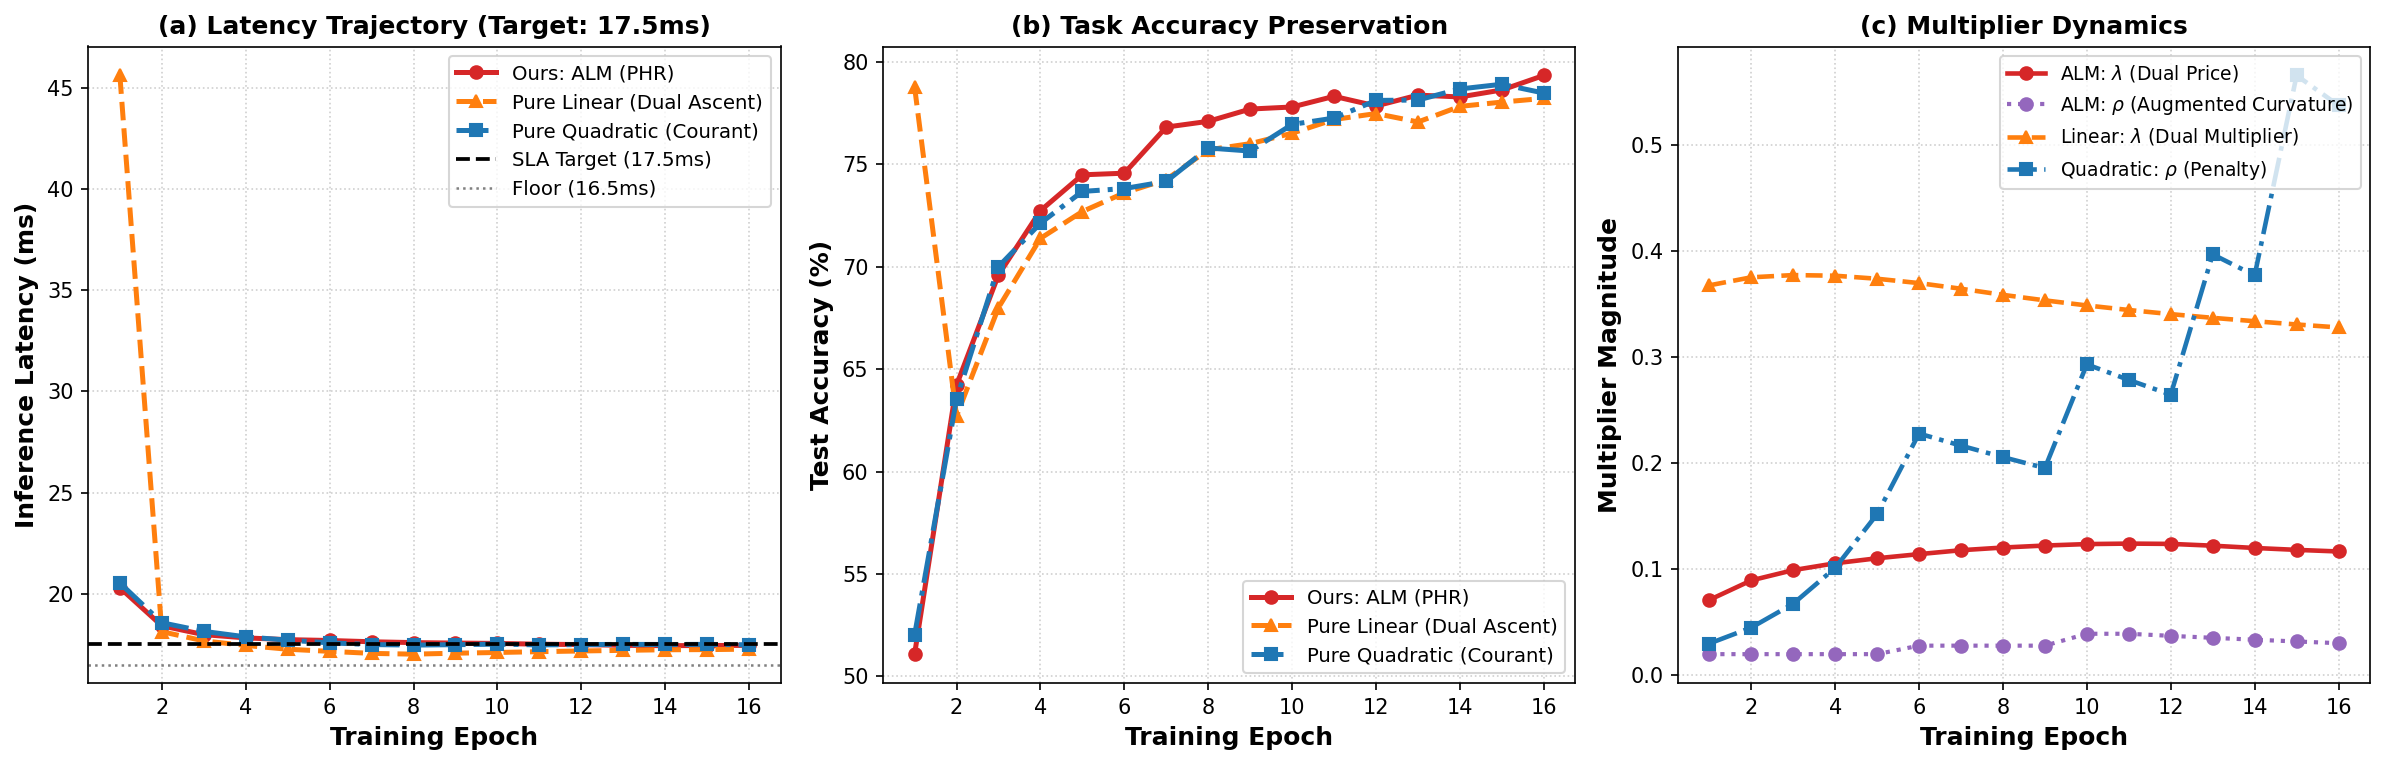

  >>> [Saved & Synced] sla_17.5ms_trajectory_16e.pdf, sla_17.5ms_trajectory_16e.png, and sla_17.5ms_ablation_16e.csv

FINAL BENCHMARK SUMMARY (ALL TARGET SLAs)
Target SLA   | Method       | Final Latency    | Violation        | Final Accuracy
------------------------------------------------------------------------------------
17.5 ms      | ALM          | 17.45 ms         | -0.05 ms (OK)    | 79.33%
17.5 ms      | LINEAR       | 17.27 ms         | -0.23 ms (OK)    | 78.21%
17.5 ms      | QUADRATIC    | 17.48 ms         | -0.02 ms (OK)    | 78.47%



In [10]:
# ==============================================================================
# Cell 8: Constrained Optimization Benchmark (ALM vs. Linear vs. Quadratic)
# (Multi-SLA Support with Non-Overwriting Dynamic File Persistence)
# ==============================================================================
import copy
import math
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------------------------
# 0. Standalone Drive & Directory Setup
# ------------------------------------------------------------------------------
OUTPUT_DIR = "/content/results"
DRIVE_BACKUP_DIR = "/content/drive/MyDrive/SemesterProject_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

drive_mounted = False
try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        drive_mounted = True
except Exception:
    pass


def sync_file(filename: str):
    """Safely mirrors files to Drive if mounted."""
    local_path = os.path.join(OUTPUT_DIR, filename)
    if drive_mounted and os.path.exists(local_path):
        try:
            shutil.copy(local_path, os.path.join(DRIVE_BACKUP_DIR, filename))
        except Exception:
            pass


# ------------------------------------------------------------------------------
# 1. Topology Setup (Case 4: Dual Heterogeneity)
# ------------------------------------------------------------------------------
nodes = {
    0: NodeConfig("Ingress", exec_time_ms=3.0),
    1: NodeConfig("Worker_A_Fast", exec_time_ms=1.5),
    2: NodeConfig("Worker_B_Slow", exec_time_ms=9.5),
    3: NodeConfig("Terminal", exec_time_ms=2.0),
}
edges = {
    (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
    (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
    (1, 3): ChannelConfig.from_mbps(60.0, 1.0),  # 60 Mbps fast link
    (2, 3): ChannelConfig.from_mbps(3.0, 1.0),   # 3 Mbps bottleneck link
}

timing_engine = DAGTimingEngine(nodes, edges)
eval_cfg = ExperimentConfig(nodes=nodes, edges=edges, lr_s=0.03, lr_c=0.008)
t_floor = timing_engine.compute_irreducible_latency()


def load_backbone_weights(model, weights_dict):
    filtered = {
        k: v for k, v in weights_dict.items() if not (k.endswith(".s") or k.endswith(".c"))
    }
    model.load_state_dict(filtered, strict=False)


def get_clean_model():
    m = CollaborativeResNetDAG(eval_cfg).to(device)
    load_backbone_weights(m, pretrained_weights)
    for name, p in m.named_parameters():
        if name.endswith(".s") or name.endswith(".c"):
            p.requires_grad = True
            if name.endswith(".s"):
                p.data.fill_(1.0)
            if name.endswith(".c"):
                p.data.zero_()
        else:
            p.requires_grad = False
    return m


# ------------------------------------------------------------------------------
# 2. Benchmark Parameters
# ------------------------------------------------------------------------------
# Set to [17.5] to stress-test the extreme tail (1.0ms above floor = 16.5ms)
# Or add multiple targets: [30.0, 24.0, 21.0, 17.5]
TARGET_SLAS = [17.5]
TRAIN_EPOCHS = 16     # 10 epochs for complete convergence

print("=" * 80)
print(f">>> CONSTRAINED OPTIMIZATION BENCHMARK (ALM vs. LINEAR vs. QUADRATIC)")
print(f">>> Target SLAs to Evaluate : {TARGET_SLAS} ms")
print(f">>> Irreducible Floor       : {t_floor:.2f} ms")
print(f">>> Training Epochs per Run : {TRAIN_EPOCHS} epochs")
print("=" * 80 + "\n")


# ------------------------------------------------------------------------------
# 3. Constrained Timing Optimizer
# ------------------------------------------------------------------------------
class ConstrainedTimingTrainer:
    def __init__(self, model, timing_engine, cfg, method: str, t_max: float):
        self.model = model.to(device)
        self.timing_engine = timing_engine
        self.cfg = cfg
        self.method = method.lower()
        self.t_max = t_max

        s_params = [bneck.s for bneck in self.model.get_bottleneck_map().values()]
        c_params = [bneck.c for bneck in self.model.get_bottleneck_map().values()]
        self.optimizer = optim.Adam(
            [{"params": s_params, "lr": cfg.lr_s}, {"params": c_params, "lr": cfg.lr_c}]
        )
        self.criterion = nn.CrossEntropyLoss()

        if self.method == "alm":
            self.lam = 0.015
            self.rho = 0.020
            self.rho_max = 5.0
        elif self.method == "linear":
            self.lam = 0.030
            self.eta_lam = 0.012
        elif self.method == "quadratic":
            self.rho = 0.020
            self.rho_max = 10.0

    def train_epoch(self, dataloader, epoch: int) -> Tuple[float, float]:
        self.model.train()
        beta = 0.1
        bneck_map = self.model.get_bottleneck_map()
        running_task_loss, running_penalty = 0.0, 0.0
        warmup = min(1.0, (epoch + 1) / 2.0)

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            self.optimizer.zero_grad()

            y_hat = self.model(x, beta=beta, deterministic=False)
            task_loss = self.criterion(y_hat, y)

            tilde_t = self.timing_engine.compute_relaxed_latency(
                bneck_map, beta=beta, alpha=self.cfg.gate.alpha
            )
            g = tilde_t - self.t_max

            if self.method == "alm":
                psi = self.lam + self.rho * g
                penalty = (torch.clamp(psi, min=0.0)**2 - self.lam**2) / (2.0 * self.rho)
            elif self.method == "linear":
                penalty = self.lam * torch.clamp(g, min=0.0)
            elif self.method == "quadratic":
                penalty = 0.5 * self.rho * (torch.clamp(g, min=0.0)**2)

            total_loss = task_loss + warmup * penalty
            total_loss.backward()
            self.optimizer.step()

            running_task_loss += task_loss.item()
            running_penalty += penalty.item()

        return running_task_loss / len(dataloader), running_penalty / len(dataloader)

    def update_multipliers(self, measured_lat: float, prev_viol: float):
        viol = measured_lat - self.t_max

        if self.method == "alm":
            self.lam = float(np.clip(self.lam + self.rho * viol, 0.001, 2.0))
            if viol > 0.0 and (prev_viol - viol) < 0.20 * max(0.1, prev_viol):
                self.rho = min(self.rho_max, self.rho * 1.4)
            elif viol <= 0.0:
                self.rho = max(0.01, self.rho * 0.95)

        elif self.method == "linear":
            self.lam = float(np.clip(self.lam + self.eta_lam * viol, 0.001, 2.0))

        elif self.method == "quadratic":
            if viol > 0.0:
                self.rho = min(self.rho_max, self.rho * 1.5)
            else:
                self.rho = max(0.01, self.rho * 0.95)

        return viol

    @torch.no_grad()
    def evaluate(self, dataloader) -> Tuple[float, float]:
        self.model.eval()
        correct, total = 0, 0
        beta_eval = self.cfg.gate.beta_min
        bneck_map = self.model.get_bottleneck_map()

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            y_hat = self.model(x, beta=beta_eval, deterministic=True)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)

        acc = 100.0 * correct / total
        lat = self.timing_engine.compute_physical_latency(bneck_map, beta=beta_eval, deterministic=True)
        return acc, lat


# ------------------------------------------------------------------------------
# 4. Master Evaluation Loop across Target SLAs
# ------------------------------------------------------------------------------
methods = ["alm", "linear", "quadratic"]
all_target_records = []

for target_sla in TARGET_SLAS:
    print(f"\n=======================================================")
    print(f"  BENCHMARKING CONSTRAINT: t_critical_path <= {target_sla:.1f} ms")
    print(f"=======================================================")

    history = {
        m: {"latency": [], "accuracy": [], "violation": [], "lam": [], "rho": []}
        for m in methods
    }

    for method in methods:
        print(f"  --> Optimizer: [{method.upper()}] (Target: {target_sla:.1f} ms)")
        model = get_clean_model()
        trainer = ConstrainedTimingTrainer(model, timing_engine, eval_cfg, method=method, t_max=target_sla)

        prev_viol = float("inf")
        for ep in range(TRAIN_EPOCHS):
            task_l, pen_l = trainer.train_epoch(train_loader, epoch=ep)
            acc, lat = trainer.evaluate(test_loader)
            viol = trainer.update_multipliers(lat, prev_viol)
            prev_viol = max(0.0, viol)

            lam_val = getattr(trainer, "lam", 0.0)
            rho_val = getattr(trainer, "rho", 0.0)

            history[method]["latency"].append(lat)
            history[method]["accuracy"].append(acc)
            history[method]["violation"].append(viol)
            history[method]["lam"].append(lam_val)
            history[method]["rho"].append(rho_val)

            viol_str = f"+{viol:.2f}ms (VIOL)" if viol > 0 else f"{viol:.2f}ms (MET)"
            print(f"      [Ep {ep+1:02d}/{TRAIN_EPOCHS}] Lat: {lat:.2f}ms ({viol_str}) | Acc: {acc:.2f}% | lam: {lam_val:.4f} | rho: {rho_val:.4f}")

        # Store final metrics
        all_target_records.append({
            "target_sla_ms": target_sla,
            "method": method.upper(),
            "final_latency_ms": history[method]["latency"][-1],
            "violation_ms": history[method]["latency"][-1] - target_sla,
            "final_accuracy_pct": history[method]["accuracy"][-1],
        })

    # Save target-specific CSV (Never overwrites other SLAs!)
    csv_filename = f"sla_{target_sla:.1f}ms_ablation_16e.csv"
    pd.DataFrame([r for r in all_target_records if r["target_sla_ms"] == target_sla]).to_csv(
        os.path.join(OUTPUT_DIR, csv_filename), index=False
    )
    sync_file(csv_filename)

    # --------------------------------------------------------------------------
    # 5. Trajectory Plot for Current Target SLA
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), dpi=150)
    epochs_range = list(range(1, TRAIN_EPOCHS + 1))

    palette = {
        "alm": ("#D62728", "o-", "Ours: ALM (PHR)"),
        "linear": ("#FF7F0E", "^--", "Pure Linear (Dual Ascent)"),
        "quadratic": ("#1F77B4", "s-.", "Pure Quadratic (Courant)")
    }

    # Panel (a): Latency Trajectory
    ax = axes[0]
    for m in methods:
        col, style, lbl = palette[m]
        ax.plot(epochs_range, history[m]["latency"], style, color=col, linewidth=2.4, markersize=6, label=lbl)

    ax.axhline(y=target_sla, color="black", linestyle="--", linewidth=1.8, label=f"SLA Target ({target_sla:.1f}ms)")
    ax.axhline(y=t_floor, color="gray", linestyle=":", linewidth=1.2, label=f"Floor ({t_floor:.1f}ms)")
    ax.set_xlabel("Training Epoch", fontsize=12, fontweight="bold")
    ax.set_ylabel("Inference Latency (ms)", fontsize=12, fontweight="bold")
    ax.set_title(f"(a) Latency Trajectory (Target: {target_sla:.1f}ms)", fontsize=12, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=9.5)

    # Panel (b): Accuracy
    ax = axes[1]
    for m in methods:
        col, style, lbl = palette[m]
        ax.plot(epochs_range, history[m]["accuracy"], style, color=col, linewidth=2.4, markersize=6, label=lbl)

    ax.set_xlabel("Training Epoch", fontsize=12, fontweight="bold")
    ax.set_ylabel("Test Accuracy (%)", fontsize=12, fontweight="bold")
    ax.set_title("(b) Task Accuracy Preservation", fontsize=12, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower right", fontsize=9.5)

    # Panel (c): Multipliers
    ax = axes[2]
    ax.plot(epochs_range, history["alm"]["lam"], "o-", color="#D62728", linewidth=2.2, label=r"ALM: $\lambda$ (Dual Price)")
    ax.plot(epochs_range, history["alm"]["rho"], "o:", color="#9467BD", linewidth=2.0, label=r"ALM: $\rho$ (Augmented Curvature)")
    ax.plot(epochs_range, history["linear"]["lam"], "^--", color="#FF7F0E", linewidth=2.2, label=r"Linear: $\lambda$ (Dual Multiplier)")
    ax.plot(epochs_range, history["quadratic"]["rho"], "s-.", color="#1F77B4", linewidth=2.2, label=r"Quadratic: $\rho$ (Penalty)")

    ax.set_xlabel("Training Epoch", fontsize=12, fontweight="bold")
    ax.set_ylabel("Multiplier Magnitude", fontsize=12, fontweight="bold")
    ax.set_title("(c) Multiplier Dynamics", fontsize=12, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=9.0)

    plt.tight_layout()

    # Dynamic target-specific file names (Preserves all previous runs!)
    pdf_name = f"sla_{target_sla:.1f}ms_trajectory_16e.pdf"
    png_name = f"sla_{target_sla:.1f}ms_trajectory_16e.png"
    plt.savefig(os.path.join(OUTPUT_DIR, pdf_name), format="pdf", bbox_inches="tight")
    plt.savefig(os.path.join(OUTPUT_DIR, png_name), format="png", dpi=300, bbox_inches="tight")
    sync_file(pdf_name)
    sync_file(png_name)

    plt.show()
    plt.close()
    print(f"  >>> [Saved & Synced] {pdf_name}, {png_name}, and {csv_filename}")


# ------------------------------------------------------------------------------
# 6. Multi-SLA Parity Plot (Generated if len(TARGET_SLAS) > 1)
# ------------------------------------------------------------------------------
df_all = pd.DataFrame(all_target_records)

print("\n" + "=" * 84)
print("FINAL BENCHMARK SUMMARY (ALL TARGET SLAs)")
print("=" * 84)
print(f"{'Target SLA':<12} | {'Method':<12} | {'Final Latency':<16} | {'Violation':<16} | {'Final Accuracy':<14}")
print("-" * 84)
for _, r in df_all.iterrows():
    viol_str = f"+{r['violation_ms']:.2f} ms" if r['violation_ms'] > 0 else f"{r['violation_ms']:.2f} ms (OK)"
    print(f"{r['target_sla_ms']:.1f} ms{'':<5} | {r['method']:<12} | {r['final_latency_ms']:.2f} ms{'':<8} | {viol_str:<16} | {r['final_accuracy_pct']:.2f}%")
print("=" * 84 + "\n")

if len(TARGET_SLAS) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=150)

    # Subplot 1: Parity Plot (y = x)
    ax = axes[0]
    min_sla, max_sla = min(TARGET_SLAS) - 1.0, max(TARGET_SLAS) + 1.0
    ax.plot([min_sla, max_sla], [min_sla, max_sla], "k--", linewidth=1.8, label="Ideal SLA Boundary (y = x)")

    styles = {
        "ALM": ("#D62728", "o-", "Ours: ALM (PHR)", 8),
        "LINEAR": ("#FF7F0E", "^--", "Pure Linear (Dual Ascent)", 8),
        "QUADRATIC": ("#1F77B4", "s-.", "Pure Quadratic (Courant)", 8),
    }

    for m in ["ALM", "LINEAR", "QUADRATIC"]:
        sub = df_all[df_all["method"] == m]
        col, style, lbl, ms = styles[m]
        ax.plot(sub["target_sla_ms"], sub["final_latency_ms"], style, color=col, linewidth=2.2, markersize=ms, label=lbl)

    ax.set_xlabel("Target SLA (ms)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Achieved Physical Latency (ms)", fontsize=13, fontweight="bold")
    ax.set_title("SLA Parity Plot (Constraint Satisfaction)", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", fontsize=10.5)

    # Subplot 2: Accuracy vs. Target SLA
    ax = axes[1]
    for m in ["ALM", "LINEAR", "QUADRATIC"]:
        sub = df_all[df_all["method"] == m]
        col, style, lbl, ms = styles[m]
        ax.plot(sub["target_sla_ms"], sub["final_accuracy_pct"], style, color=col, linewidth=2.2, markersize=ms, label=lbl)

    ax.set_xlabel("Target SLA (ms)", fontsize=13, fontweight="bold")
    ax.set_ylabel("CIFAR-10 Test Accuracy (%)", fontsize=13, fontweight="bold")
    ax.set_title("Accuracy vs. Target SLA", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower right", fontsize=10.5)

    plt.tight_layout()

    parity_pdf = "multi_sla_parity_comparison.pdf"
    parity_png = "multi_sla_parity_comparison.png"
    plt.savefig(os.path.join(OUTPUT_DIR, parity_pdf), format="pdf", bbox_inches="tight")
    plt.savefig(os.path.join(OUTPUT_DIR, parity_png), format="png", dpi=300, bbox_inches="tight")
    sync_file(parity_pdf)
    sync_file(parity_png)
    plt.show()
    plt.close()

    df_all.to_csv(os.path.join(OUTPUT_DIR, "multi_sla_benchmark_summary.csv"), index=False)
    sync_file("multi_sla_benchmark_summary.csv")
    print(f">>> [Saved & Synced Multi-SLA Parity Comparison]")